<a href="https://colab.research.google.com/github/JourdynLuv/JourdynLuv/blob/main/1_3_Data_Visualization_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab Instructions

You have been hired by a record executive to design a guaranteed smash hit song based on data.  The exec has decided that if you make a song that has all the most popular features of recent songs then it will definitely be a hit.  So if - for example - the most common key in the Spotify data is C# then we would want the song we are designing to also be in C#.  If a "typical" value of BPM is between 120 and 130 then we would want the song we are designing to also have a tempo between 120 and 130 BMP.

Visualize and describe the distribution of:
* BPM
* Key
* Mode
* Danceability
* Energy
* Speechiness
* Acousticness

Based on your visualizations and calculations, what values for each of these features would make a song a guaranteed smash hit?  For quantitative features, you should propose a range of values.

Use a large language model to help you write code to identify if there are any songs in the Spotify dataset that meet all of the criteria we determined.  What is/are the artist(s) and title(s) of the song?  Were any of these songs actually popular?

Pick a song that you know was a smash hit. How do the values of BPM, key, mode, danceability, etc. compare to other songs?

**Hint:**  Import the Spotify data using `df = pd.read_csv('spotify-2023.csv', encoding='ISO-8859-1')`.

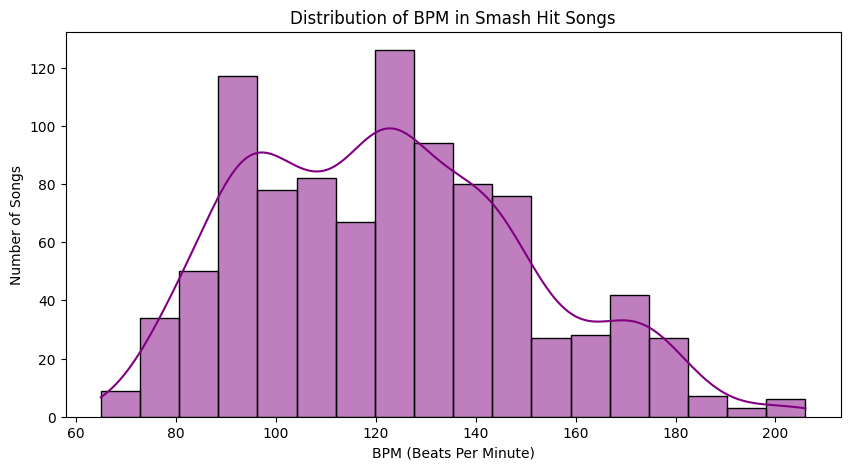

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/spotify-2023.csv', encoding='ISO-8859-1')

plt.figure(figsize=(10, 5))
sns.histplot(df['bpm'], kde=True, color='purple')

plt.title("Distribution of BPM in Smash Hit Songs")
plt.xlabel("BPM (Beats Per Minute)")
plt.ylabel("Number of Songs")

plt.show()

The distribution of the BPM shows that the most typical tempo for a good song is between 120 and 130 BPMM with the second popular range being 90 to 100 BPM.

/tmp/ipykernel_1431/759278093.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='key', palette='mako', order=df['key'].value_counts().index)


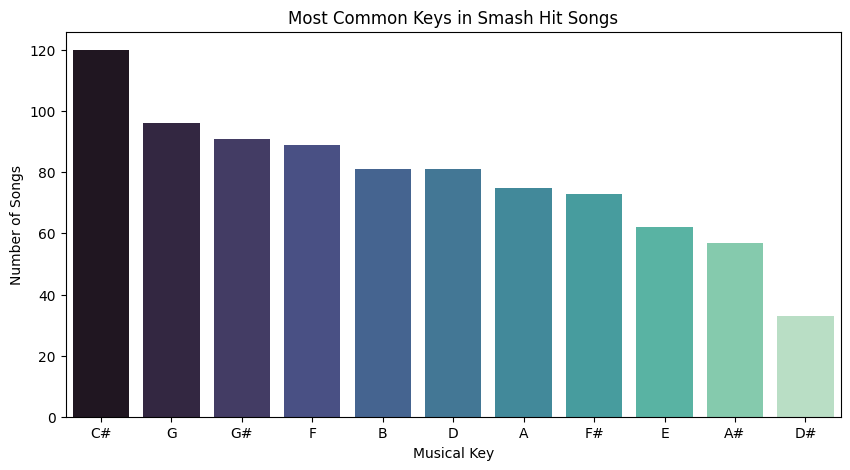

In [5]:
plt.figure(figsize=(10, 5))

sns.countplot(data=df, x='key', palette='mako', order=df['key'].value_counts().index)

plt.title("Most Common Keys in Smash Hit Songs")
plt.xlabel("Musical Key")
plt.ylabel("Number of Songs")

plt.show()

The distribution of musical keys show that C# is the most common key for good songs, followed by G and G#.

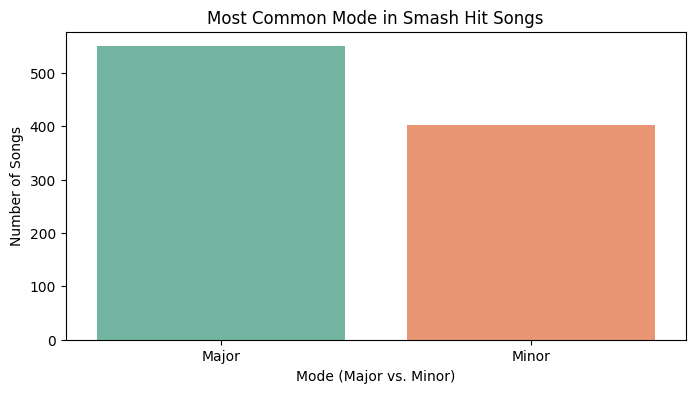

In [6]:
plt.figure(figsize=(8, 4))

sns.countplot(data=df, x='mode', palette='Set2', hue='mode')

plt.title("Most Common Mode in Smash Hit Songs")
plt.xlabel("Mode (Major vs. Minor)")
plt.ylabel("Number of Songs")

plt.show()

The distribution shows that more hit songs are written in major more than they are minor.

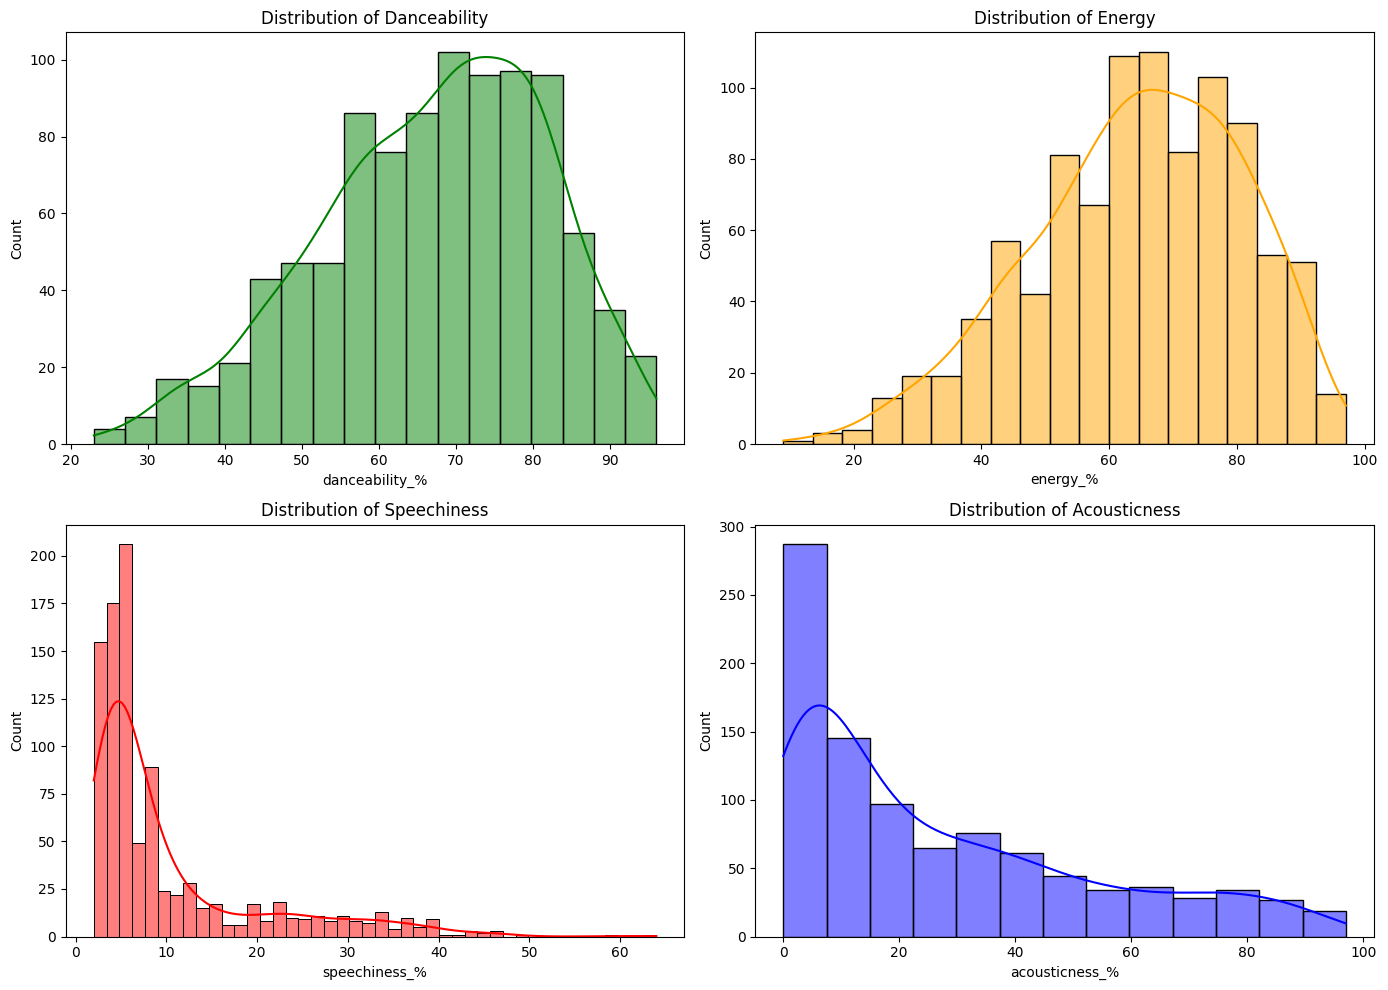

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df['danceability_%'], kde=True, color='green', ax=axes[0, 0])
axes[0, 0].set_title("Distribution of Danceability")

sns.histplot(df['energy_%'], kde=True, color='orange', ax=axes[0, 1])
axes[0, 1].set_title("Distribution of Energy")

sns.histplot(df['speechiness_%'], kde=True, color='red', ax=axes[1, 0])
axes[1, 0].set_title("Distribution of Speechiness")

sns.histplot(df['acousticness_%'], kde=True, color='blue', ax=axes[1, 1])
axes[1, 1].set_title("Distribution of Acousticness")

plt.tight_layout()
plt.show()

Danceability - The distro leans towards the higher end with a lot of the big hits being toward 60% and 80%

Energy - The energy is also concentrated between 60% and 85% as that is where the peaks are.

Speechiness - A lot of the hit songs have a lot speechiness score around 0-10%.

Acousticness - This is skewed heavily toward the left in lower values as most hits fall under 20%.

In [10]:
ultimate_songs = df[
    (df['key'] == 'C#') &
    (df['mode'] == 'Major') &
    (df['bpm'] >= 120) & (df['bpm'] <= 130) &
    (df['danceability_%'] >= 65) & (df['danceability_%'] <= 85) &
    (df['energy_%'] >= 60) & (df['energy_%'] <= 85) &
    (df['speechiness_%'] <= 10) &
    (df['acousticness_%'] <= 20)
]

ultimate_songs[['artist(s)_name', 'track_name', 'streams']]

,artist(s)_name,track_name,streams
168,"Rihanna, Calvin Harris",We Found Love,1235005533
236,"Kendrick Lamar, Beyoncï¿",AMERICA HAS A PROBLEM (feat. Kendrick Lamar),57089066
778,Bad Bunny,Dos Mil 16,338422004


The songs that met all the requirements where by Rihanna, Kendrick, Beyonce, and Bad Bunny, and while these songs where not something I enjoyed, they were indeed big hits during the times they where out.


In [11]:
my_song = df[df['track_name'].str.contains("fukumean", case=False, na=False)]

my_song[['track_name', 'artist(s)_name', 'bpm', 'key', 'mode', 'danceability_%', 'energy_%', 'speechiness_%', 'acousticness_%']]

,track_name,artist(s)_name,bpm,key,mode,danceability_%,energy_%,speechiness_%,acousticness_%
8,fukumean,Gunna,130,C#,Minor,85,62,9,12


For my song I chose a song by gunna called fukumean, its BPM is 130, which is a little at the top of the hit range, its in the key of C# and Minor, its Danceability is 85% and energy is 62% and as well as the other stats which all fit well within the range if not a little more or less than the other test suggest.
